[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sterolose/sirius-statistics-2026/blob/main/notebooks/4_two_means.ipynb)

## Семинар 4. Сравнение средних двух выборок

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

Поработаем с датасетом [Anorexia](https://vincentarelbundock.github.io/Rdatasets/doc/MASS/anorexia.html). Он содержит измерения веса 72 молодых пациенток с нервной анорексией до и после периода наблюдения.

Столбцы содержат следующие переменные:
- `rowname` — индекс пациентки;
- `Treat` — группа исследования:
  - `Cont` — контрольная группа, 26 пациенток;
  - `CBT` — когнитивно-поведенческая терапия, 29 пациенток;
  - `FT` — семейная терапия, 17 пациенток.
- `Prewt` — вес до периода наблюдения, в фунтах;
- `Postwt` — вес после периода наблюдения, в фунтах.

Скачаем CSV-файл в папку `../data`. Команда `mkdir -p` создаст ее, если она отсутствует.

In [2]:
%%bash
mkdir -p ../data
wget -O ../data/anorexia.csv https://vincentarelbundock.github.io/Rdatasets/csv/MASS/anorexia.csv

--2026-10-06 09:20:09--  https://vincentarelbundock.github.io/Rdatasets/csv/MASS/anorexia.csv
Resolving vincentarelbundock.github.io (vincentarelbundock.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to vincentarelbundock.github.io (vincentarelbundock.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1234 (1.2K) [text/csv]
Saving to: ‘../data/anorexia.csv’

     0K .                                                     100% 77.1M=0s

2026-10-06 09:20:09 (77.1 MB/s) - ‘../data/anorexia.csv’ saved [1234/1234]



In [3]:
df = pd.read_csv("../data/anorexia.csv")
df.head(2)

,rownames,Treat,Prewt,Postwt
0,1,Cont,80.7,80.2
1,2,Cont,89.4,80.1


Давайте сделаем датафрейм чуть читабельнее и переведем вес в килограммы.

In [4]:
df = df.drop(columns="rownames")
df = df.rename(
    columns={
        "Treat": "treatment",
        "Prewt": "W_before",
        "Postwt": "W_after",
    }
)

df["W_before"] = df["W_before"] * 0.45359237
df["W_after"] = df["W_after"] * 0.45359237

df.head(2)

,treatment,W_before,W_after
0,Cont,36.604904,36.378108
1,Cont,40.551158,36.332749


Во всех заданиях используем уровень значимости $\alpha = 0.05$ и двусторонние альтернативы.

### Задание 1

Оценим нормальность распределения для всего датасета. Построим гистограмму и Q–Q plot как для исходного, так и для конечной массы тела, а затем выполним тест Шапиро — Уилка.

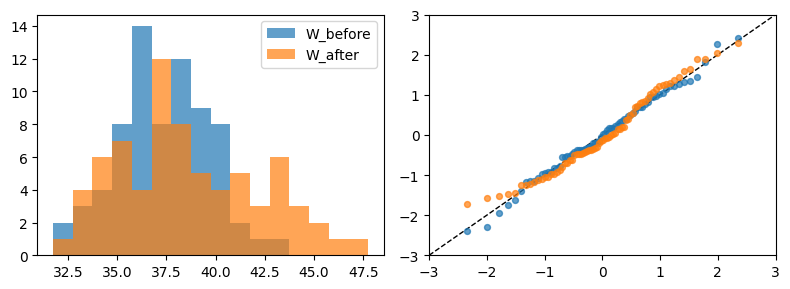

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

w_cols = ["W_before", "W_after"]
w_values = df[w_cols].to_numpy()
bins = np.arange(w_values.min(), w_values.max() + 1)

for var in w_cols:
    values = df[var]
    axes[0].hist(values, bins=bins, alpha=0.7, label=var)

    z = stats.zscore(values, ddof=1)
    theoretical, observed = stats.probplot(z, dist="norm", fit=False)
    axes[1].scatter(theoretical, observed, s=18, alpha=0.7)

axes[1].plot([-3, 3], [-3, 3], "k--", linewidth=1, zorder=0)
axes[1].set(xlim=(-3, 3), ylim=(-3, 3))
axes[0].legend()

plt.tight_layout()
plt.show()

In [6]:
pd.Series({
    var: stats.shapiro(df[var]).pvalue for var in ["W_before", "W_after"]
}, name="p-value").to_frame()

,p-value
W_before,0.948353
W_after,0.057809


Повторите аналогичную проверку нормальности обоих переменных для всех трех групп.  
Графики изобразите на сетке 3 × 2, а результаты тестов оформите через `pd.DataFrame`.

In [ ]:
# Your code here

С помощью `.groupby` оцените среднее и стандартное отклонение отдельно для трех групп.

In [8]:
df.groupby('treatment').agg(['mean', 'std']).T.round(2)

treatment        CBT   Cont     FT
W_before mean  37.51  36.99  37.75
         std    2.20   2.59   2.28
W_after  mean  38.87  36.79  41.05
         std    3.79   2.15   3.84

### Задание 2

Сравним исходный вес в группах `CBT` и `Cont` с помощью t-критерия. За что отвечает параметр `equal_var`? Попробуем выполнить тест с разными его значениями.

In [9]:
control = df.loc[df["treatment"] == "Cont", "W_before"]
cbt = df.loc[df["treatment"] == "CBT", "W_before"]

student = stats.ttest_ind(control, cbt, equal_var=True)
welch = stats.ttest_ind(control, cbt, equal_var=False)

pd.DataFrame({
    "test": ["Student", "Welch"],
    "statistic": [student.statistic, welch.statistic],
    "p-value": [student.pvalue, welch.pvalue],
})

,test,statistic,p-value
0,Student,-0.795370,0.429946
1,Welch,-0.788231,0.434332


Далее по умолчанию будем использовать тест Уэлча. Аналогично выполните проверку на различие среднего веса после терапии для этих двух групп.  
Отвергаем ли мы нулевую гипотезу?

In [10]:
control = df.loc[df["treatment"] == "Cont", "W_before"]
cbt = df.loc[df["treatment"] == "CBT", "W_before"]

welch = stats.ttest_ind(control, cbt, equal_var=False)

pd.DataFrame({
    "test": ["Welch"],
    "statistic": [welch.statistic],
    "p-value": [welch.pvalue],
})

,test,statistic,p-value
0,Welch,-0.788231,0.434332


### Задание 3

Для оценки динамики веса у одной и той же пациентки введем новую переменную:
$$
\Delta W = W_{\mathrm{after}} - W_{\mathrm{before}}.
$$

In [11]:
df["delta_W"] = df["W_after"] - df["W_before"]
df.groupby("treatment", sort=False)["delta_W"].agg(["mean", "std"]).T.round(2)

treatment,Cont,CBT,FT
mean,-0.20,1.36,3.30
std,3.62,3.32,3.25


Оцените распределение новой величины на нормальность для группы `FT`.

In [12]:
stats.shapiro(df.delta_W)

ShapiroResult(statistic=np.float64(0.9746643621441187), pvalue=np.float64(0.15441412470060406))

### Задание 4

С помощью парного теста Стьюдента роверьте, изменился ли вес в группе `FT` в среднем. Для этого используйте `stats.ttest_rel`.

In [13]:
stats.ttest_rel(df['W_before'], df['W_after'])

TtestResult(statistic=np.float64(-2.9375697188906673), pvalue=np.float64(0.004457718078670148), df=np.int64(71))

Проверьте нулевую гипотезу о том, что среднее изменение веса равно нулю, с помощью одновыборочного t-теста для `delta_W`. Для этого используйте `stats.ttest_1samp` с параметром `popmean=0`. Сравните статистику и p-value с результатом парного t-теста.

In [14]:
stats.ttest_1samp(df['delta_W'], 0)

TtestResult(statistic=np.float64(2.9375697188906673), pvalue=np.float64(0.004457718078670148), df=np.int64(71))

### Задание 5

Проверьте, различается ли среднее изменение веса между группами `CBT` и `FT` с помощью двухвыборочного t-теста Уэлча. Выведите значение статистики и p-value.

In [15]:
cbt = df[df["treatment"] == 'CBT']
ft = df[df["treatment"] == 'FT']

stats.ttest_ind(cbt["delta_W"], ft['delta_W'])

TtestResult(statistic=np.float64(-1.921575473042316), pvalue=np.float64(0.06115116461729568), df=np.float64(44.0))